# 04 - Surface Generation

## Aim
This notebook translates image clustering results into grayscale height maps for 3D surface generation.

The goal is to convert visual cluster logic into architectural surface behaviour and export the resulting height maps for further development in Blender.

## Strategy
Two feature systems are used:

- **CLIP cluster** defines macro-scale surface type
- **HOG cluster** defines micro-scale surface behaviour

The output is a set of height maps that can be applied as displacement maps in Blender.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
cluster_dir = Path("../outputs/clustering")
output_dir = Path("../outputs/heightmaps")

output_dir.mkdir(parents=True, exist_ok=True)

cluster_file = cluster_dir / "vectorisation_clusters_named.csv"

print("Cluster file:", cluster_file.resolve())
print("Output dir:", output_dir.resolve())

Cluster file: D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\clustering\vectorisation_clusters_named.csv
Output dir: D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\heightmaps


In [3]:
df_vectors = pd.read_csv(cluster_file)

print("Rows:", len(df_vectors))
df_vectors.head()

Rows: 100


,image_path,hog_pc1,hog_pc2,clip_pc1,clip_pc2,hog_cluster,clip_cluster,hog_name,surface_effect,clip_name,surface_type
0,..\data\images_resized\img_0.jpg,-37.235604,52.282169,-7.563570,-2.050971,2,1,repetitive grid,modular repetition,monolithic concrete mass,monolithic surface
1,..\data\images_resized\img_1.jpg,-81.423371,-17.679044,3.738815,1.446424,3,3,high-contrast edges,sharp displacement,open structural frame,skeletal/open surface
2,..\data\images_resized\img_10.jpg,17.359458,55.767711,4.340713,-0.536242,1,3,directional perspective,directional stretch,open structural frame,skeletal/open surface
3,..\data\images_resized\img_11.jpg,-11.866050,-94.736109,3.575356,-2.405537,3,3,high-contrast edges,sharp displacement,open structural frame,skeletal/open surface
4,..\data\images_resized\img_12.jpg,21.472503,12.789464,0.890370,-5.157659,1,3,directional perspective,directional stretch,open structural frame,skeletal/open surface


In [4]:
def normalize_array(Z):
    Z = Z - Z.min()
    if Z.max() > 0:
        Z = Z / Z.max()
    return Z


def save_heightmap(Z, save_path):
    Z_norm = normalize_array(Z)
    img = (Z_norm * 255).astype(np.uint8)
    Image.fromarray(img).save(save_path)

In [5]:
def generate_macro_surface(surface_type="grid_surface", size=256):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)

    if surface_type == "layered_surface":
        Z = np.sin(Y * 8) * 0.7 + np.sin(X * 3) * 0.3

    elif surface_type == "monolithic_surface":
        Z = np.exp(-(X**2 + Y**2) * 2.5)

    elif surface_type == "grid_surface":
        Z = np.sin(X * 10) * np.sin(Y * 10)

    elif surface_type == "skeletal/open_surface":
        Z = np.abs(np.sin(X * 8)) * 0.6 + np.abs(np.sin(Y * 4)) * 0.4

    else:
        Z = np.zeros((size, size))

    return normalize_array(Z)

In [6]:
def apply_hog_modifier(Z, hog_name):
    size = Z.shape[0]
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    X, Y = np.meshgrid(x, y)

    Z_mod = Z.copy()

    if hog_name == "multi-directional structure":
        Z_mod = Z_mod + 0.08 * np.sin(X * 12 + Y * 10)

    elif hog_name == "directional perspective":
        gradient = np.linspace(0.6, 1.2, size)
        gradient = np.tile(gradient, (size, 1))
        Z_mod = Z_mod * gradient

    elif hog_name == "repetitive grid":
        Z_mod = np.round(Z_mod * 3) / 3

    elif hog_name == "high-contrast edges":
        Z_mod = (Z_mod > 0.5).astype(float)

    return normalize_array(Z_mod)

In [7]:
def generate_surface(clip_name, hog_name, size=256):
    clip_to_surface = {
        "complex urban brutalism": "layered_surface",
        "monolithic concrete mass": "monolithic_surface",
        "facade repetition": "grid_surface",
        "open structural frame": "skeletal/open_surface"
    }

    surface_type = clip_to_surface.get(clip_name, "grid_surface")

    Z = generate_macro_surface(surface_type=surface_type, size=size)
    Z = apply_hog_modifier(Z, hog_name)

    return normalize_array(Z)

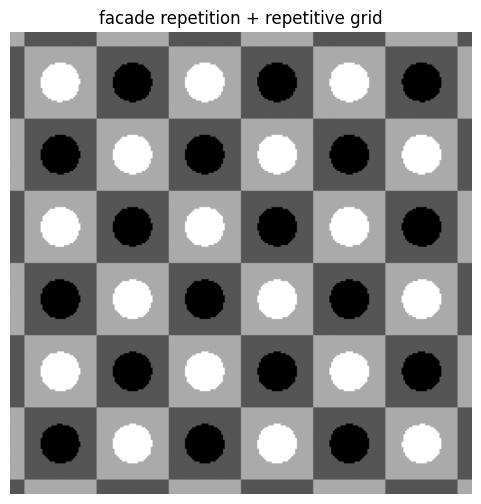

In [8]:
selected_clip_name = "facade repetition"
selected_hog_name = "repetitive grid"

Z = generate_surface(selected_clip_name, selected_hog_name, size=256)

plt.figure(figsize=(6, 6))
plt.imshow(Z, cmap="gray")
plt.title(f"{selected_clip_name} + {selected_hog_name}")
plt.axis("off")
plt.show()

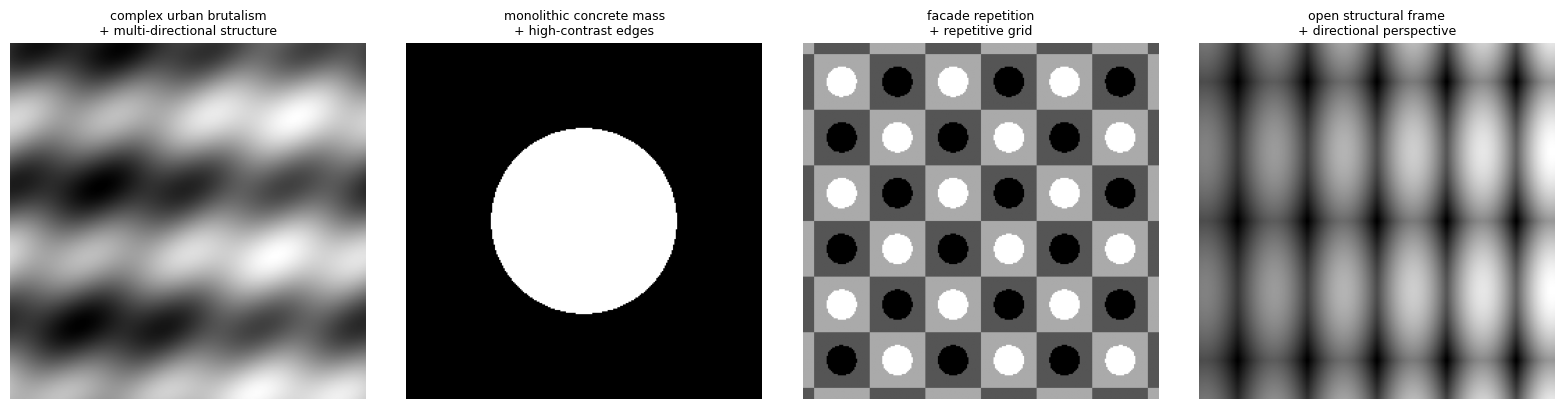

In [9]:
test_combinations = [
    ("complex urban brutalism", "multi-directional structure"),
    ("monolithic concrete mass", "high-contrast edges"),
    ("facade repetition", "repetitive grid"),
    ("open structural frame", "directional perspective"),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (clip_name, hog_name) in zip(axes, test_combinations):
    Z = generate_surface(clip_name, hog_name, size=256)
    ax.imshow(Z, cmap="gray")
    ax.set_title(f"{clip_name}\n+ {hog_name}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

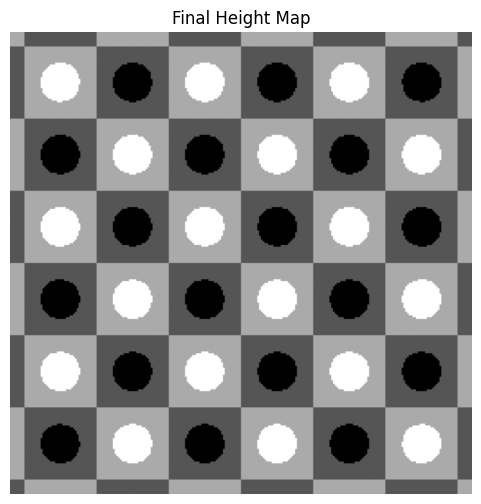

In [10]:
final_clip_name = "facade repetition"
final_hog_name = "repetitive grid"

final_Z = generate_surface(final_clip_name, final_hog_name, size=256)

plt.figure(figsize=(6, 6))
plt.imshow(final_Z, cmap="gray")
plt.title("Final Height Map")
plt.axis("off")
plt.show()

In [11]:
final_path = output_dir / "final_heightmap.png"
save_heightmap(final_Z, final_path)

print("Final height map saved to:")
print(final_path.resolve())

Final height map saved to:
D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\heightmaps\final_heightmap.png


In [12]:
def save_scaled_heightmap(Z, scale_name, gamma, save_dir):
    Z_scaled = normalize_array(Z) ** gamma
    save_heightmap(Z_scaled, save_dir / f"final_heightmap_{scale_name}.png")


save_scaled_heightmap(final_Z, "soft", gamma=1.5, save_dir=output_dir)
save_scaled_heightmap(final_Z, "normal", gamma=1.0, save_dir=output_dir)
save_scaled_heightmap(final_Z, "strong", gamma=0.7, save_dir=output_dir)

print("Saved: soft / normal / strong versions")

Saved: soft / normal / strong versions


In [13]:
all_exports = []

for clip_name in sorted(df_vectors["clip_name"].dropna().unique()):
    for hog_name in sorted(df_vectors["hog_name"].dropna().unique()):
        Z = generate_surface(clip_name, hog_name, size=256)

        filename = f"{clip_name}__{hog_name}".replace(" ", "_").replace("/", "-")
        save_path = output_dir / f"{filename}.png"

        save_heightmap(Z, save_path)

        all_exports.append({
            "clip_name": clip_name,
            "hog_name": hog_name,
            "file": str(save_path)
        })

df_exports = pd.DataFrame(all_exports)
df_exports.head()

,clip_name,hog_name,file
0,complex urban brutalism,directional perspective,..\outputs\heightmaps\complex_urban_brutalism_...
1,complex urban brutalism,high-contrast edges,..\outputs\heightmaps\complex_urban_brutalism_...
2,complex urban brutalism,multi-directional structure,..\outputs\heightmaps\complex_urban_brutalism_...
3,complex urban brutalism,repetitive grid,..\outputs\heightmaps\complex_urban_brutalism_...
4,facade repetition,directional perspective,..\outputs\heightmaps\facade_repetition__direc...


In [14]:
export_index_path = output_dir / "heightmap_index.csv"
df_exports.to_csv(export_index_path, index=False)

print("Saved export index to:")
print(export_index_path.resolve())

Saved export index to:
D:\Work\Workspace\Projects\Python\data-driven-surface\outputs\heightmaps\heightmap_index.csv


## Interpretation

This notebook translates visual clustering results into procedural surface behaviour.

- **CLIP clusters** control macro-scale surface type, such as monolithic mass, layered systems, repetitive facades, or open structural frames.
- **HOG clusters** control micro-scale behaviour, such as directional bias, grid repetition, contrast sharpening, or multi-directional variation.

The resulting height maps can be interpreted as architectural reliefs, facade studies, or displacement maps for 3D surface generation in Blender.

## Blender Workflow

Use the exported `final_heightmap.png` in Blender with:

- Grid mesh (200 x 200)
- Subdivision Surface modifier
- Displace modifier
- Coordinates: UV
- Direction: Z
- Strength: test between 0.2 and 0.6
- Midlevel: 0.5

Suggested additional modifiers:
- Solidify
- Bevel
- Simple Deform (Bend) for curved wall experiments